In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# <span style="color:red"> ch01. NLTK 자연어 처리 패키지 </span>
# 1. NLTK 패키지
- 자연어 처리를 위한 강력하고 사용하기 쉬운 라이브러리
1. 텍스트 전처리 : 토큰화(문장->형태소/어절), 정규화(정규표현식 활용), 불용어 제거, 표제어 추출(기본형태로 변환)
2. 품사태깅 : 단어 품사 식별
3. 어휘 데이터 베이스 사용
4. 구조화된 문서의 빈도수, 분류분석, 연관분석, 감정분석 (단점) 속도가 느림

``` 
pip install nltk==3.7
```

In [2]:
import nltk

In [4]:
# 말뭉치를 다운로드
# c:/nltk_data or d:/nltk_data or 
# c:/Users/내컴퓨터이름/anconda3/nltk_data
# c:/Users/내컴퓨터이름/anconda3/lib/nltk_data
# c:/Users/내컴퓨터이름/anaconda3/share/nltk_data
# c:/Users/내컴퓨터이름/anaconda3/share/nltk_data
# C:\Users\Admin\AppData\Roaming\nltk_data
nltk.download()


showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [6]:
nltk.corpus.gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [13]:
# 말뭉치 데이터 셋 (소설 엠마 내용)
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
print('글자수 :',len(emma))

# sent_tokenize() : 문장 단위로 나눠 list로 반환
from nltk.tokenize import sent_tokenize
sent_tokens = sent_tokenize(emma)
# sent_tokens[:3]
print('문장수 :',len(sent_tokens))
print("%r" % sent_tokens[5])  # "%r" % 로우데이터 그래도 출력 (ex. \n 같은 것들 포함)

글자수 : 887071
문장수 : 7456
"Even before Miss Taylor had ceased to hold the nominal\noffice of governess, the mildness of her temper had hardly allowed\nher to impose any restraint; and the shadow of authority being\nnow long passed away, they had been living together as friend and\nfriend very mutually attached, and Emma doing just what she liked;\nhighly esteeming Miss Taylor's judgment, but directed chiefly by\nher own."


In [15]:
# word_tokenize() : 단어 토큰으로 쪼개 list로 반환
from nltk.tokenize import word_tokenize

print(word_tokenize(sent_tokens[5]))
word_tokens = word_tokenize(emma)
print('단어수 :',len(word_tokens))

['Even', 'before', 'Miss', 'Taylor', 'had', 'ceased', 'to', 'hold', 'the', 'nominal', 'office', 'of', 'governess', ',', 'the', 'mildness', 'of', 'her', 'temper', 'had', 'hardly', 'allowed', 'her', 'to', 'impose', 'any', 'restraint', ';', 'and', 'the', 'shadow', 'of', 'authority', 'being', 'now', 'long', 'passed', 'away', ',', 'they', 'had', 'been', 'living', 'together', 'as', 'friend', 'and', 'friend', 'very', 'mutually', 'attached', ',', 'and', 'Emma', 'doing', 'just', 'what', 'she', 'liked', ';', 'highly', 'esteeming', 'Miss', 'Taylor', "'s", 'judgment', ',', 'but', 'directed', 'chiefly', 'by', 'her', 'own', '.']
단어수 : 191776


In [17]:
# 정규표현식을 이용한 불용어 처리
# RegexpTokenizer() 토큰화할때 해당 정규 표현식에 해당하는 word만 적용
from nltk.tokenize import RegexpTokenizer
digitRet = RegexpTokenizer('\d+')
alphaRet = RegexpTokenizer('\w+')
digits = digitRet.tokenize(sent_tokens[0])
digits
words = alphaRet.tokenize(sent_tokens[0])
words

['Emma',
 'by',
 'Jane',
 'Austen',
 '1816',
 'VOLUME',
 'I',
 'CHAPTER',
 'I',
 'Emma',
 'Woodhouse',
 'handsome',
 'clever',
 'and',
 'rich',
 'with',
 'a',
 'comfortable',
 'home',
 'and',
 'happy',
 'disposition',
 'seemed',
 'to',
 'unite',
 'some',
 'of',
 'the',
 'best',
 'blessings',
 'of',
 'existence',
 'and',
 'had',
 'lived',
 'nearly',
 'twenty',
 'one',
 'years',
 'in',
 'the',
 'world',
 'with',
 'very',
 'little',
 'to',
 'distress',
 'or',
 'vex',
 'her']

# 2. 형태소(의미있는 가장 작은 단위) 분석

In [20]:
words2 = ['sending', 'cooking', 'sing', 'rock', 'files', 'lives', 'crying']
# 어간추출(1) : PorterStemmer
from nltk.stem import PorterStemmer
pst = PorterStemmer()
pst.stem(words2[2])

'sing'

In [21]:
[pst.stem(word) for word in words2]

['send', 'cook', 'sing', 'rock', 'file', 'live', 'cri']

In [22]:
# 어간추출(2) : LancasterStemmer - 어간추출하는 것 중 제일 빈도 높음
from nltk.stem import LancasterStemmer
lst = LancasterStemmer()
[lst.stem(word) for word in words2]

['send', 'cook', 'sing', 'rock', 'fil', 'liv', 'cry']

In [23]:
# 어간추출(3) : RegexpStemmer - 정규표현식에 해다하는 부분만 어간 추출
from nltk.stem import RegexpStemmer
rst = RegexpStemmer('ing')
[rst.stem(word) for word in words2]

['send', 'cook', 's', 'rock', 'files', 'lives', 'cry']

In [26]:
# 품사 태깅
from nltk.tag import pos_tag
tagged_list = pos_tag(word_tokenize(sent_tokens[0]))
tagged_list

[('[', 'NNS'),
 ('Emma', 'NNP'),
 ('by', 'IN'),
 ('Jane', 'NNP'),
 ('Austen', 'NNP'),
 ('1816', 'CD'),
 (']', 'NNP'),
 ('VOLUME', 'NNP'),
 ('I', 'PRP'),
 ('CHAPTER', 'VBP'),
 ('I', 'PRP'),
 ('Emma', 'NNP'),
 ('Woodhouse', 'NNP'),
 (',', ','),
 ('handsome', 'NN'),
 (',', ','),
 ('clever', 'NN'),
 (',', ','),
 ('and', 'CC'),
 ('rich', 'JJ'),
 (',', ','),
 ('with', 'IN'),
 ('a', 'DT'),
 ('comfortable', 'JJ'),
 ('home', 'NN'),
 ('and', 'CC'),
 ('happy', 'JJ'),
 ('disposition', 'NN'),
 (',', ','),
 ('seemed', 'VBD'),
 ('to', 'TO'),
 ('unite', 'VB'),
 ('some', 'DT'),
 ('of', 'IN'),
 ('the', 'DT'),
 ('best', 'JJS'),
 ('blessings', 'NNS'),
 ('of', 'IN'),
 ('existence', 'NN'),
 (';', ':'),
 ('and', 'CC'),
 ('had', 'VBD'),
 ('lived', 'VBN'),
 ('nearly', 'RB'),
 ('twenty-one', 'CD'),
 ('years', 'NNS'),
 ('in', 'IN'),
 ('the', 'DT'),
 ('world', 'NN'),
 ('with', 'IN'),
 ('very', 'RB'),
 ('little', 'JJ'),
 ('to', 'TO'),
 ('distress', 'VB'),
 ('or', 'CC'),
 ('vex', 'VB'),
 ('her', 'PRP'),
 ('.', '.')

## 퀴즈 : emma 소설 안에서
1. 특수문자가 들어가지 않는 3글자 이상의 단어만 추출해서 품사태깅을 하시오
2. Emma 단어가 몇번 등장하며, 품사 태깅이 어떤 품사들로 되어 있는지 모두 출력하시오
3. 내가 원하는 품사(명사)의 단어만 뽑아 등장하는 명사의 종류와 개수를 출력하시오

In [56]:
# 1번
alphaRet = RegexpTokenizer('\w{3,}')
quiz1 = alphaRet.tokenize(emma)
taged_quiz1 = pos_tag(quiz1)
print('emma 소설의 3글자 이상의 단어 출현 수 :', len(taged_quiz1))
print('emma 소설의 3글자 이상의 단어 종류 수 :', len(set(taged_quiz1)))

emma 소설의 3글자 이상의 단어 출현 수 : 123877
emma 소설의 3글자 이상의 단어 종류 수 : 11678


In [47]:
# 2. Emma 단어가 몇번 등장하며, 품사 태깅이 어떤 품사들로 되어 있는지 모두 출력하시오
print('Emma가 등장한 횟수 : ', quiz1.count('Emma'))
print('Emma의 품사 태깅 : ', set([tag for word, tag in taged_quiz1 if word=='Emma']))

Emma가 등장한 횟수 :  865
Emma의 품사 태깅 :  {'NN', 'JJ', 'VBP', 'NNS', 'NNPS', 'VBN', 'NNP', 'VB', 'RB', 'VBD'}


In [63]:
pos = [tag for word, tag in taged_quiz1 if word=='Emma']
print('Emma가 등장한 횟수 : ', len(pos))
print('Emma의 품사 태깅 : ', set(pos))

Emma가 등장한 횟수 :  865
Emma의 품사 태깅 :  {'NN', 'JJ', 'VBP', 'NNS', 'NNPS', 'VBN', 'NNP', 'VB', 'RB', 'VBD'}


In [64]:
# 3. 내가 원하는 품사(명사)의 단어만 뽑아 등장하는 명사의 종류와 개수를 출력하시오
noun_list = [word for word, tag in taged_quiz1 if tag =='NN' or tag == 'NNS' or tag =='NNP' or tag == 'NNPS']
print('명사가 나온 횟수 : ', len(noun_list))
print('출현한 명사의 종류 수 : ', len(set(noun_list)))
print('한 단어가 나오는 평균 빈도수 : ',  len(noun_list) / len(set(noun_list)) )

명사가 나온 횟수 :  30781
출현한 명사의 종류 수 :  4165
한 단어가 나오는 평균 빈도수 :  7.3903961584633855


### 🏷️ 품사 태그 상세 설명
<br>
    <table style="margin-left: 0;">
      <thead>
        <tr>
          <th align="left">Tag</th>
          <th align="left">품사</th>
          <th align="left">설명</th>
        </tr>
      </thead>
      <tbody>
        <tr><td>CC</td><td>등위 접속사</td><td>and, but, or 등 대등한 단어/문장 연결</td></tr>
        <tr><td>CD</td><td>기수</td><td>one, two, 100 등 숫자</td></tr>
        <tr><td>DT</td><td>한정사</td><td>the, a, an, this 등 명사를 한정</td></tr>
        <tr><td>EX</td><td>존재형 there</td><td>“There is...”에서의 there (존재를 나타냄)</td></tr>
        <tr><td>FW</td><td>외래어</td><td>비영어 외국어 단어 (라틴어, 독일어 등)</td></tr>
        <tr><td>IN</td><td>전치사/종속 접속사</td><td>in, of, because, although 등 절/구 연결</td></tr>
        <tr><td>JJ</td><td>형용사</td><td>good, blue, fast 등 명사 수식</td></tr>
        <tr><td>JJR</td><td>비교급 형용사</td><td>better, taller 등</td></tr>
        <tr><td>JJS</td><td>최상급 형용사</td><td>best, tallest 등</td></tr>
        <tr><td>LS</td><td>리스트 마커</td><td>(1), (A), i. 등 리스트 표기 요소</td></tr>
        <tr><td>MD</td><td>조동사</td><td>can, will, should, must 등 동사 앞에 붙어 조절</td></tr>
        <tr><td>NN</td><td>일반 명사 (단수)</td><td>dog, apple, idea 등</td></tr>
        <tr><td>NNS</td><td>일반 명사 (복수)</td><td>dogs, apples 등</td></tr>
        <tr><td>NNP</td><td>고유 명사 (단수)</td><td>Korea, John 등</td></tr>
        <tr><td>NNPS</td><td>고유 명사 (복수)</td><td>Americans, Beatles 등</td></tr>
        <tr><td>PDT</td><td>전한정사</td><td>all, both 등 한정사 앞에 붙는 한정사</td></tr>
        <tr><td>POS</td><td>소유격 어미</td><td>’s (Tom’s car의 ’s)</td></tr>
        <tr><td>PRP</td><td>인칭 대명사</td><td>I, you, he, she, it, we, they</td></tr>
        <tr><td>PRP\$</td><td>소유 대명사</td><td>my, your, his, her, its, our, their</td></tr>
        <tr><td>RB</td><td>부사</td><td>quickly, very, never 등</td></tr>
        <tr><td>RBR</td><td>비교급 부사</td><td>more quickly, better 등</td></tr>
        <tr><td>RBS</td><td>최상급 부사</td><td>most quickly, best 등</td></tr>
        <tr><td>RP</td><td>소사 (동사 구성 부사)</td><td>off, up, down (give up, take off 등)</td></tr>
        <tr><td>TO</td><td>to</td><td>to 부정사에서의 to (to go, to eat 등)</td></tr>
        <tr><td>UH</td><td>감탄사</td><td>oh, wow, hey 등</td></tr>
        <tr><td>VB</td><td>동사 원형</td><td>go, eat, run 등</td></tr>
        <tr><td>VBD</td><td>동사 과거형</td><td>went, ate, ran 등</td></tr>
        <tr><td>VBG</td><td>현재분사/동명사</td><td>going, eating 등</td></tr>
        <tr><td>VBN</td><td>과거분사</td><td>gone, eaten 등</td></tr>
        <tr><td>VBP</td><td>현재형 (1·2인칭)</td><td>I go, you run 등</td></tr>
        <tr><td>VBZ</td><td>현재형 (3인칭 단수)</td><td>He goes, she runs 등</td></tr>
        <tr><td>WDT</td><td>wh-한정사</td><td>which, whatever 등</td></tr>
        <tr><td>WP</td><td>wh-대명사</td><td>who, what 등</td></tr>
        <tr><td>WP\$</td><td>소유형 wh-대명사</td><td>whose 등</td></tr>
        <tr><td>WRB</td><td>wh-부사</td><td>when, where, why, how 등</td></tr>
  </tbody>
</table>

In [60]:
# taged_quiz1에서 각 품사별 몇개 태그되었는지
pos_cnt = dict() # 빈 딕셔너리
for word, tag in taged_quiz1:
    if word =='Emma':
        if tag in pos_cnt:
            pos_cnt[tag] += 1
        else:
            pos_cnt[tag] = 1
pos_cnt

{'NNP': 838,
 'VBP': 4,
 'JJ': 4,
 'VB': 5,
 'NNS': 2,
 'RB': 1,
 'NN': 7,
 'NNPS': 2,
 'VBN': 1,
 'VBD': 1}

In [62]:
# taged_quiz1에서 각 품사별 몇개 태그되었는지
import pandas as pd
pos = [tag for word, tag in taged_quiz1 if word=='Emma']
pos_cnt = pd.Series([0]*len(set(pos)), index=set(pos))
for word, tag in taged_quiz1:
    if word =='Emma':
        pos_cnt[tag] += 1
        
pos_cnt.sort_values(ascending=False)

NNP     838
NN        7
VB        5
JJ        4
VBP       4
NNS       2
NNPS      2
VBN       1
RB        1
VBD       1
dtype: int64

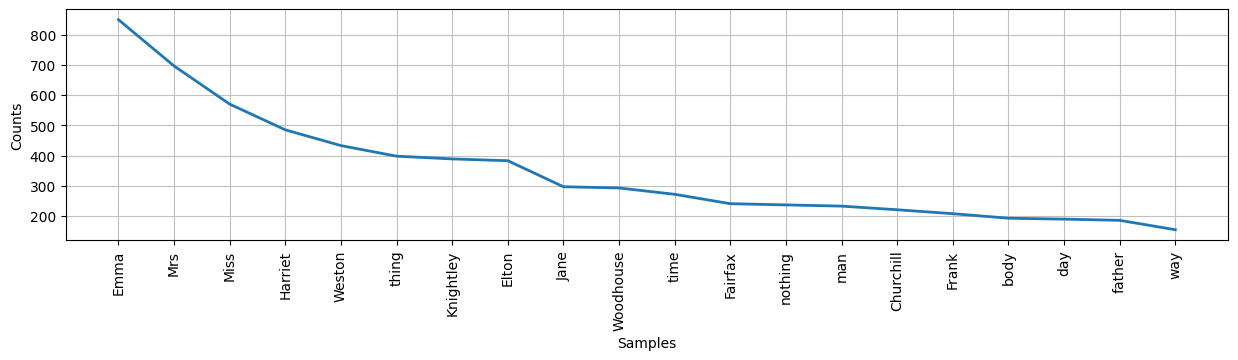

In [66]:
# 최빈단어 시각화
import matplotlib.pyplot as plt
from nltk import Text
emma_text = Text(noun_list)
plt.figure(figsize=(15,3))
emma_text.plot(20)
plt.show()

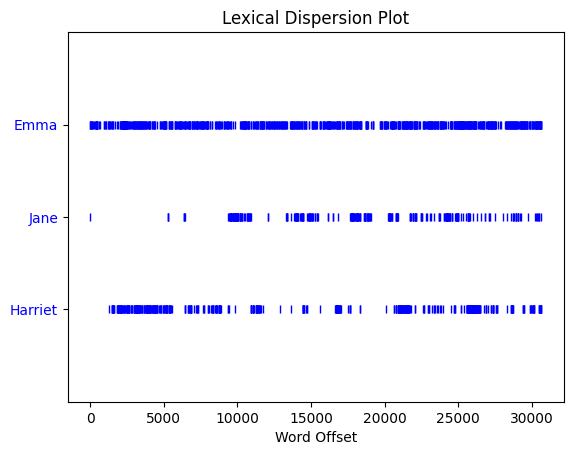

In [67]:
# dispersion_plot : 분산 플롯, 언제 특정 단어가 등장하는지 시각화
emma_text.dispersion_plot(['Emma', 'Jane', 'Harriet'])

In [73]:
# 고유명사
names_list = [word for word, tag in taged_quiz1 if tag=='NNP' or tag=='NNPS']
print('고유명사의 개수 :', len(set(names_list)))
# FreqDist(리스트) : 리스트 내 키워드의 빈도를 반환. 단 딕셔너리 형태이지만, 딕셔너리는 아니라 변환을 해줘야 한다.
from nltk import FreqDist
dic = dict(FreqDist(names_list))
# 시리즈로 바꿔야 정렬이 가능해진다.
wordcnt = pd.Series(dic)
wordcnt.sort_values(ascending=False, inplace=True)
wordcnt.head(10)

고유명사의 개수 : 654


Emma         840
Mrs          696
Miss         569
Harriet      484
Weston       433
Knightley    389
Elton        382
Jane         295
Woodhouse    293
Fairfax      241
dtype: int64

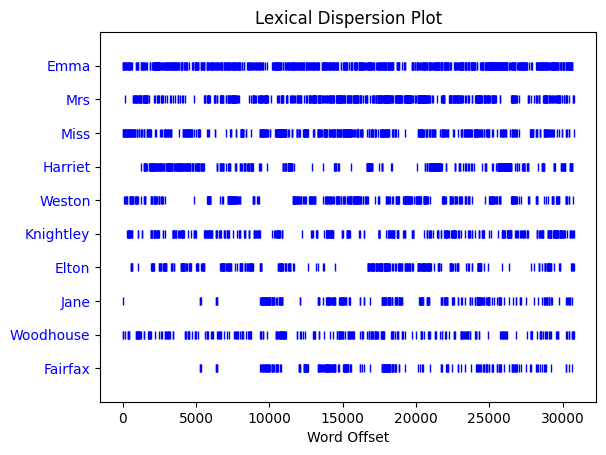

In [79]:
emma_text.dispersion_plot(list(wordcnt.head(10).index))